# Preterm Birth Prediction Model (EHG/TPEHG)
## Work Plan

1. **Setup & Configuration**: Define hyperparameters, paths, and model configurations globally.
2. **Data Loading & Preprocessing**: 
   - Load `.npz` file and split into Train, Validation, and Test sets (Stratified).
   - Normalize the input signals using Standard Scaling (fit on train, applied to val/test).
   - The Test set is kept completely isolated until final evaluation.
3. **Handling Imbalance**: 
   - Use `WeightedRandomSampler` to oversample the minority class during training.
   - Calculate positive class weights for the loss function if needed.
4. **Model Architecture**:
   - Utilize a placeholder structure for the `PhysioWave-emg` backbone.
   - Attempt to download pre-trained weights. If successful, perform Transfer Learning. If it fails, train from scratch.
5. **Training**:
   - Train the model using an explicit loop in PyTorch.
   - Apply `EarlyStopping` to monitor validation loss and prevent overfitting.
6. **Evaluation**:
   - Calculate performance metrics (F1, Precision, Recall, Accuracy).
   - Visualize Training/Validation Loss and Accuracy, along with the Confusion Matrix.

In [1]:
# Run this cell to mount Google Drive if you are running in Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import urllib.request
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# GLOBAL CONFIGURATION
# ==========================================
DATA_PATH = '/content/drive/MyDrive/deep_birth/data/tpehg/processed_data.npz'
DUMMY_MODEL_URL = 'https://dummy-link-for-physiowave-emg-weights.com/weights.pth'
WEIGHTS_PATH = 'physiowave_emg_weights.pth'

BATCH_SIZE = 16
EPOCHS = 100
LEARNING_RATE = 1e-4
RANDOM_SEED = 42
TEST_SIZE = 0.15
VAL_SIZE = 0.15 # 0.15 of total data -> roughly 0.176 of the remaining 0.85

# Ensure reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cpu


In [3]:
# ==========================================
# DATA PROCESSING MODULE
# ==========================================

def load_and_split_data(path, test_size=TEST_SIZE, val_size=VAL_SIZE, random_state=RANDOM_SEED):
    """
    Loads data from .npz file and splits it into Train, Validation, and Test sets.
    The Test set will remain completely untouched.
    """
    print(f"Loading data from {path}...")
    # try:
    data = np.load(path)
    # Assuming the standard keys 'X' and 'y', modify if the npz keys are different
    X = data['X'] if 'X' in data.files else data[data.files[0]]
    y = data['y'] if 'y' in data.files else data[data.files[1]]
    # except Exception as e:
        # print(f"Failed to load real data, creating dummy data for demonstration. Error: {e}")
        # # Dummy data for demonstration since we might not have access to the real file right now
        # X = np.random.randn(300, 1, 1000) # 300 samples, 1 channel, 1000 sequence length
        # y = np.zeros(300)
        # y[:38] = 1 # 38 positive cases
        # np.random.shuffle(y)

    print(f"Total samples: {len(y)}, Positive cases: {sum(y)}")
    
    # Stratified split to ensure the 38 positive cases are distributed correctly
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    
    # Calculate relative validation size
    val_relative = val_size / (1.0 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_relative, stratify=y_temp, random_state=random_state
    )
    
    print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
    print(f"Val shapes: X={X_val.shape}, y={y_val.shape}")
    print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = load_and_split_data(DATA_PATH)

Loading data from /content/drive/MyDrive/deep_birth/data/tpehg/processed_data.npz...
Total samples: 300, Positive cases: 38
Train shapes: X=(210, 3, 15060), y=(210,)
Val shapes: X=(45, 3, 15060), y=(45,)
Test shapes: X=(45, 3, 15060), y=(45,)


In [4]:
class EHGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def create_dataloaders(X_train, X_val, X_test, y_train, y_val, y_test, batch_size=BATCH_SIZE):
    """
    Normalizes data and prepares PyTorch DataLoaders with WeightedRandomSampler for training.
    """
    # Normalization (Standard Scaling)
    # Reshape for scaling: (N, C, L) -> (N, C*L)
    orig_shape_train = X_train.shape
    orig_shape_val = X_val.shape
    orig_shape_test = X_test.shape
    
    X_train_flat = X_train.reshape(orig_shape_train[0], -1)
    X_val_flat = X_val.reshape(orig_shape_val[0], -1)
    X_test_flat = X_test.reshape(orig_shape_test[0], -1)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_flat).reshape(orig_shape_train)
    X_val_scaled = scaler.transform(X_val_flat).reshape(orig_shape_val)
    X_test_scaled = scaler.transform(X_test_flat).reshape(orig_shape_test)
    
    # Calculate weights for the WeightedRandomSampler to handle class imbalance
    class_counts = np.bincount(y_train.astype(int))
    class_weights = 1. / class_counts
    sample_weights = np.array([class_weights[int(label)] for label in y_train])
    sample_weights = torch.DoubleTensor(sample_weights)
    
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    
    # Create datasets
    train_dataset = EHGDataset(X_train_scaled, y_train)
    val_dataset = EHGDataset(X_val_scaled, y_val)
    test_dataset = EHGDataset(X_test_scaled, y_test)
    
    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = create_dataloaders(X_train, X_val, X_test, y_train, y_val, y_test)

In [5]:
# ==========================================
# MODEL ARCHITECTURE
# ==========================================

class PhysioWaveEMG(nn.Module):
    """
    Dummy representation of the PhysioWave-emg backbone.
    In practice, this would have a more complex structure designed for signals (e.g., 1D CNNs).
    """
    def __init__(self, in_channels=1):
        super(PhysioWaveEMG, self).__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1)
        )
        self.feature_dim = 32

    def forward(self, x):
        # Handle inputs that might be (Batch, Length) without channels
        if len(x.shape) == 2:
            x = x.unsqueeze(1)
        x = self.features(x)
        return x.view(x.size(0), -1)

class PretermPredictionModel(nn.Module):
    def __init__(self, backbone):
        super(PretermPredictionModel, self).__init__()
        self.backbone = backbone
        self.classifier = nn.Sequential(
            nn.Linear(self.backbone.feature_dim, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        features = self.backbone(x)
        out = self.classifier(features)
        return out

def get_model(in_channels=1):
    backbone = PhysioWaveEMG(in_channels=in_channels)
    
    # Attempt to download weights
    transfer_learning = False
    print(f"Attempting to download PhysioWave-emg weights from: {DUMMY_MODEL_URL}")
    try:
        urllib.request.urlretrieve(DUMMY_MODEL_URL, WEIGHTS_PATH)
        # Assuming the weights are successfully downloaded
        backbone.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
        transfer_learning = True
        print("[SUCCESS] Base model downloaded. Performing Transfer Learning.")
    except Exception as e:
        print(f"[FAILED] Could not download base model: {e}")
        print("----> Training the model from scratch.")
        
    model = PretermPredictionModel(backbone)
    return model, transfer_learning

model, is_transfer_learning = get_model(in_channels=X_train.shape[1])
model.to(DEVICE)
print(model)

Attempting to download PhysioWave-emg weights from: https://dummy-link-for-physiowave-emg-weights.com/weights.pth
[FAILED] Could not download base model: <urlopen error [Errno -2] Name or service not known>
----> Training the model from scratch.
PretermPredictionModel(
  (backbone): PhysioWaveEMG(
    (features): Sequential(
      (0): Conv1d(3, 16, kernel_size=(7,), stride=(2,), padding=(3,))
      (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): AdaptiveAvgPool1d(output_size=1)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3)

In [6]:
# ==========================================
# TRAINING MODULE
# ==========================================

class EarlyStopping:
    def __init__(self, patience=15, min_delta=0, path='best_model.pth'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)

class ModelTrainer:
    def __init__(self, model, train_loader, val_loader, criterion, optimizer, device=DEVICE):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        self.early_stopping = EarlyStopping(patience=15, path='best_model.pth')
        
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    def train(self, epochs):
        for epoch in range(epochs):
            # Training Phase
            self.model.train()
            train_loss = 0.0
            correct_train = 0
            total_train = 0
            
            for X_batch, y_batch in self.train_loader:
                X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                
                self.optimizer.zero_grad()
                outputs = self.model(X_batch)
                loss = self.criterion(outputs, y_batch)
                loss.backward()
                self.optimizer.step()
                
                train_loss += loss.item() * X_batch.size(0)
                preds = torch.sigmoid(outputs) >= 0.5
                correct_train += (preds == y_batch).sum().item()
                total_train += y_batch.size(0)
                
            train_loss = train_loss / len(self.train_loader.dataset)
            train_acc = correct_train / total_train
            
            # Validation Phase
            self.model.eval()
            val_loss = 0.0
            correct_val = 0
            total_val = 0
            
            with torch.no_grad():
                for X_batch, y_batch in self.val_loader:
                    X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                    outputs = self.model(X_batch)
                    loss = self.criterion(outputs, y_batch)
                    
                    val_loss += loss.item() * X_batch.size(0)
                    preds = torch.sigmoid(outputs) >= 0.5
                    correct_val += (preds == y_batch).sum().item()
                    total_val += y_batch.size(0)
                    
            val_loss = val_loss / len(self.val_loader.dataset)
            val_acc = correct_val / total_val
            
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)
            
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
            
            self.early_stopping(val_loss, self.model)
            if self.early_stopping.early_stop:
                print("Early stopping triggered.")
                break
                
        # Load best model
        self.model.load_state_dict(torch.load('best_model.pth'))
        return self.history

In [7]:
# ==========================================
# EXECUTE TRAINING
# ==========================================

# Using BCEWithLogitsLoss. We don't necessarily need pos_weight here 
# because we are already using WeightedRandomSampler to balance the batches.
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

trainer = ModelTrainer(model, train_loader, val_loader, criterion, optimizer)
history = trainer.train(EPOCHS)

Epoch 1/100 | Train Loss: 0.6908 | Val Loss: 0.7336 | Train Acc: 0.5238 | Val Acc: 0.1333
Epoch 2/100 | Train Loss: 0.7070 | Val Loss: 0.7338 | Train Acc: 0.4667 | Val Acc: 0.1333
EarlyStopping counter: 1 out of 15
Epoch 3/100 | Train Loss: 0.6943 | Val Loss: 0.7300 | Train Acc: 0.5286 | Val Acc: 0.1333
Epoch 4/100 | Train Loss: 0.6898 | Val Loss: 0.7296 | Train Acc: 0.5476 | Val Acc: 0.1333
Epoch 5/100 | Train Loss: 0.6939 | Val Loss: 0.7311 | Train Acc: 0.5000 | Val Acc: 0.1333
EarlyStopping counter: 1 out of 15
Epoch 6/100 | Train Loss: 0.6844 | Val Loss: 0.7312 | Train Acc: 0.5524 | Val Acc: 0.1333
EarlyStopping counter: 2 out of 15
Epoch 7/100 | Train Loss: 0.6827 | Val Loss: 0.7329 | Train Acc: 0.5810 | Val Acc: 0.1333
EarlyStopping counter: 3 out of 15
Epoch 8/100 | Train Loss: 0.6877 | Val Loss: 0.7343 | Train Acc: 0.5333 | Val Acc: 0.1333
EarlyStopping counter: 4 out of 15
Epoch 9/100 | Train Loss: 0.6805 | Val Loss: 0.7343 | Train Acc: 0.5952 | Val Acc: 0.1333
EarlyStopping c

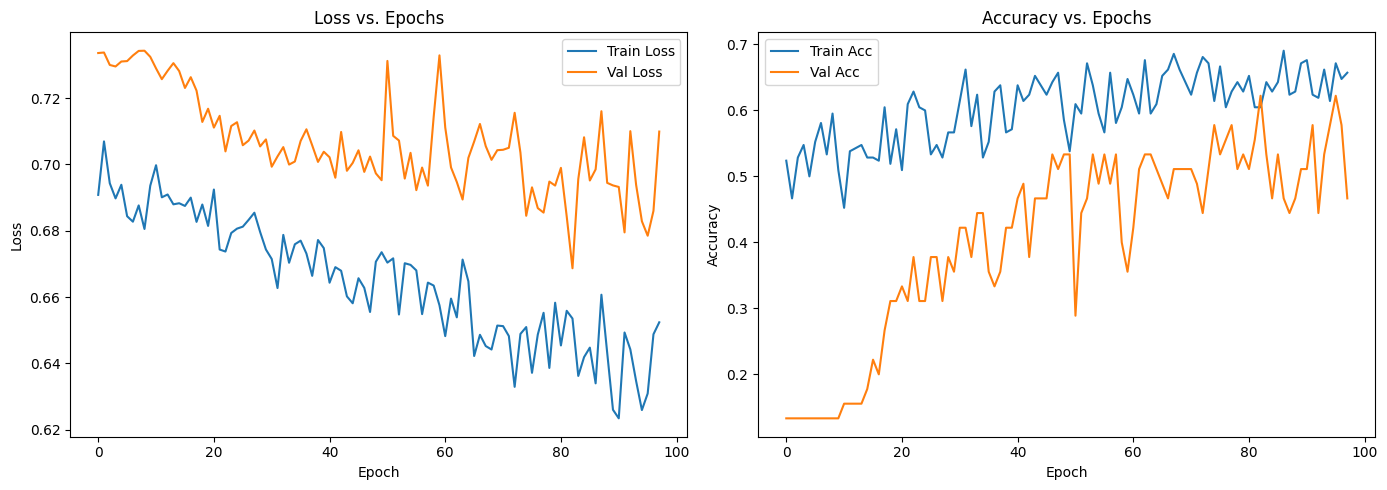

--- Test Set Evaluation ---
Accuracy:  0.5778
Precision: 0.1579
Recall:    0.5000
F1-Score:  0.2400


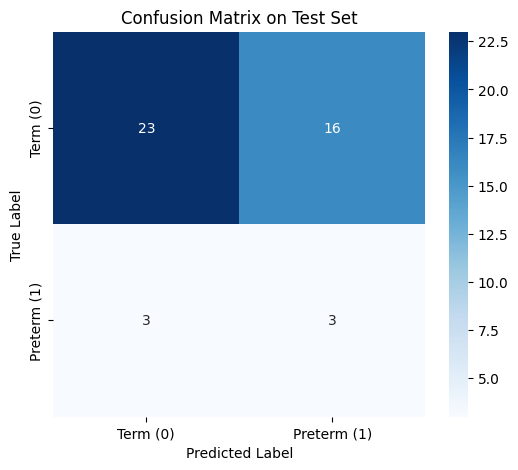

In [8]:
# ==========================================
# EVALUATION MODULE
# ==========================================

class Evaluator:
    def __init__(self, model, test_loader, device=DEVICE):
        self.model = model
        self.test_loader = test_loader
        self.device = device

    def evaluate(self):
        self.model.eval()
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for X_batch, y_batch in self.test_loader:
                X_batch = X_batch.to(self.device)
                outputs = self.model(X_batch)
                preds = (torch.sigmoid(outputs) >= 0.5).cpu().numpy()
                
                all_preds.extend(preds)
                all_targets.extend(y_batch.numpy())
                
        all_preds = np.array(all_preds)
        all_targets = np.array(all_targets)
        
        acc = accuracy_score(all_targets, all_preds)
        prec = precision_score(all_targets, all_preds, zero_division=0)
        rec = recall_score(all_targets, all_preds, zero_division=0)
        f1 = f1_score(all_targets, all_preds, zero_division=0)
        cm = confusion_matrix(all_targets, all_preds)
        
        print("--- Test Set Evaluation ---")
        print(f"Accuracy:  {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall:    {rec:.4f}")
        print(f"F1-Score:  {f1:.4f}")
        
        return cm

    def plot_history(self, history):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        axes[0].plot(history['train_loss'], label='Train Loss')
        axes[0].plot(history['val_loss'], label='Val Loss')
        axes[0].set_title('Loss vs. Epochs')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        
        axes[1].plot(history['train_acc'], label='Train Acc')
        axes[1].plot(history['val_acc'], label='Val Acc')
        axes[1].set_title('Accuracy vs. Epochs')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()

    def plot_confusion_matrix(self, cm):
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Term (0)', 'Preterm (1)'], 
                    yticklabels=['Term (0)', 'Preterm (1)'])
        plt.title('Confusion Matrix on Test Set')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()

# Run Evaluation
evaluator = Evaluator(model, test_loader)
evaluator.plot_history(history)
cm = evaluator.evaluate()
evaluator.plot_confusion_matrix(cm)